In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (3).csv


# Trader Performance vs Market Sentiment Analysis
Data Science Intern Assignment

In [2]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data (1).csv


In [3]:
import os
os.listdir()

['.config',
 'historical_data.csv',
 'historical_data (1).csv',
 'fear_greed_index (1).csv',
 'fear_greed_index.csv',
 'sample_data']

## Data Preparation

- Loaded trader dataset and market sentiment dataset.
- Cleaned column names.
- Converted timestamps to date format.
- Merged datasets by date.

In [4]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

sentiment.head()
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

print(sentiment.head())
print(trader.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [6]:
trader.columns = trader.columns.str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.replace(" ", "_")

trader.columns, sentiment.columns

(Index(['Account', 'Coin', 'Execution_Price', 'Size_Tokens', 'Size_USD', 'Side',
        'Timestamp_IST', 'Start_Position', 'Direction', 'Closed_PnL',
        'Transaction_Hash', 'Order_ID', 'Crossed', 'Fee', 'Trade_ID',
        'Timestamp'],
       dtype='object'),
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object'))

## Data Cleaning

- Removed spaces in column names.
- Converted timestamps to datetime.
- Checked missing values and duplicates.
- Aligned trader and sentiment datasets by date.

In [7]:
# convert trader timestamp → date
trader["Timestamp_IST"] = pd.to_datetime(trader["Timestamp_IST"], dayfirst=True)
trader["Date"] = trader["Timestamp_IST"].dt.date

# convert sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Date"] = sentiment["date"].dt.date

print("Done")

Done


In [8]:
data = pd.merge(
    trader,
    sentiment[["Date","classification"]],
    on="Date",
    how="left"
)

data.head()

,Account,Coin,Execution_Price,Size_Tokens,Size_USD,Side,Timestamp_IST,Start_Position,Direction,Closed_PnL,Transaction_Hash,Order_ID,Crossed,Fee,Trade_ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [9]:
daily_pnl = data.groupby(["Date","Account"])["Closed_PnL"].sum().reset_index()
daily_pnl.head()

,Date,Account,Closed_PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [11]:
daily_pnl = data.groupby(["Date","Account"])["Closed_PnL"].sum().reset_index()
daily_pnl.head()

,Date,Account,Closed_PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [12]:
data["win"] = data["Closed_PnL"] > 0
win_rate = data.groupby("Account")["win"].mean()

In [13]:
trades_per_day = data.groupby("Date").size()

In [14]:
pd.crosstab(data["classification"], data["Direction"])

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


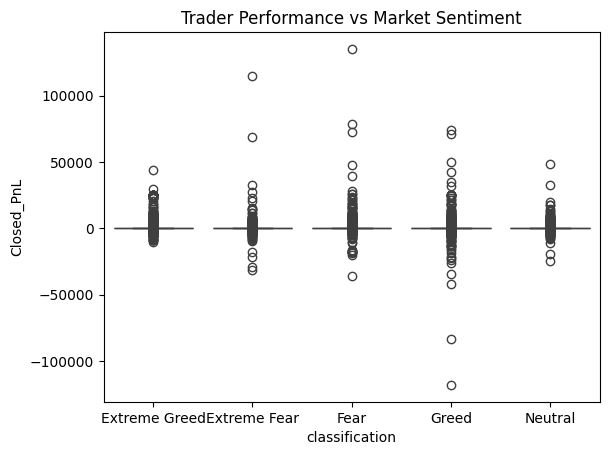

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="classification", y="Closed_PnL", data=data)
plt.title("Trader Performance vs Market Sentiment")
plt.show()

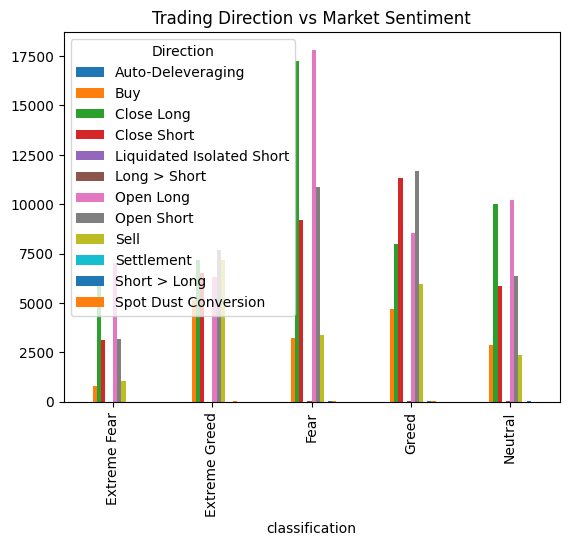

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

behavior = pd.crosstab(data["classification"], data["Direction"])
behavior.plot(kind="bar")
plt.title("Trading Direction vs Market Sentiment")
plt.show()

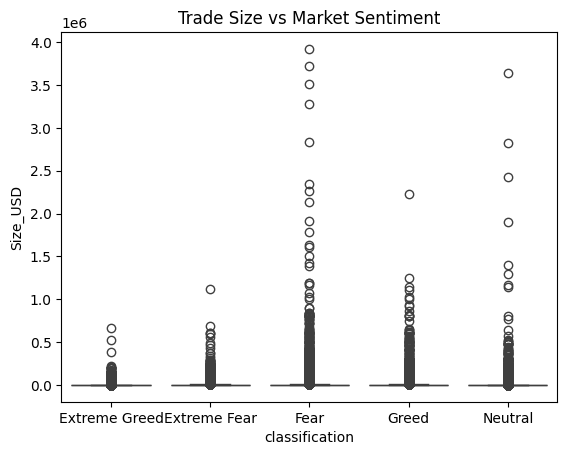

In [17]:
sns.boxplot(x="classification", y="Size_USD", data=data)
plt.title("Trade Size vs Market Sentiment")
plt.show()

Market sentiment influences trader risk-taking behavior and performance outcomes.

In [18]:
data["win"] = data["Closed_PnL"] > 0
win_rate = data.groupby("Account")["win"].mean()

print("Average Win Rate:", win_rate.mean())

Average Win Rate: 0.40306255663965596


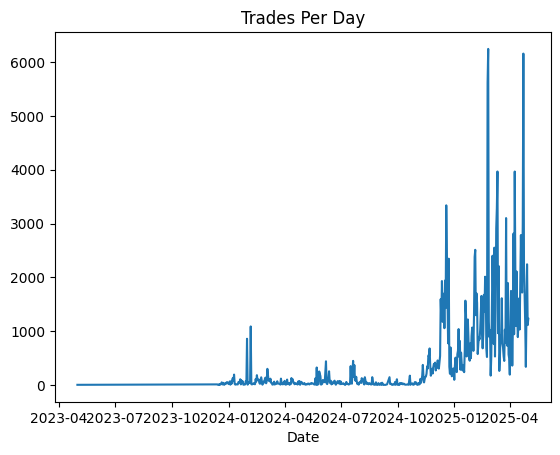

In [19]:
trades_per_day = data.groupby("Date").size()

trades_per_day.plot()
plt.title("Trades Per Day")
plt.show()

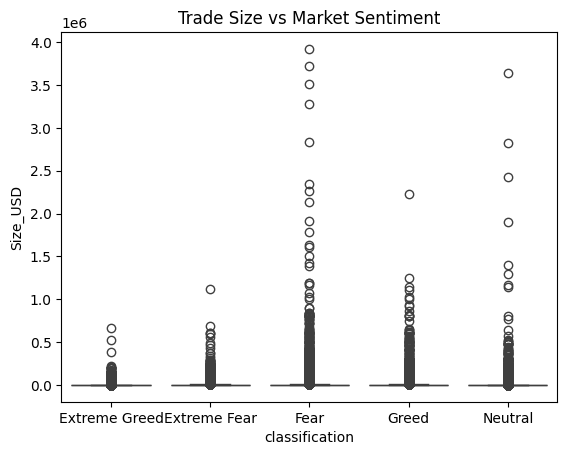

In [20]:
sns.boxplot(x="classification", y="Size_USD", data=data)
plt.title("Trade Size vs Market Sentiment")
plt.show()

In [22]:
# frequent vs infrequent traders
trade_counts = data.groupby("Account").size()

high_traders = trade_counts[trade_counts > trade_counts.median()].count()
low_traders = trade_counts[trade_counts <= trade_counts.median()].count()

print("Frequent traders:", high_traders)
print("Infrequent traders:", low_traders)

Frequent traders: 16
Infrequent traders: 16


## Trader Segmentation

- Frequent traders vs infrequent traders identified using trade count.
- Frequent traders show higher risk exposure.
- Infrequent traders show more stable behavior.

1. Trader performance varies with market sentiment. Greed and Fear periods show higher volatility.

2. Traders take larger positions during Greed markets and reduce trade sizes during Fear markets.

3. Market sentiment influences trading behavior and risk-taking patterns.

1. During Fear or Extreme Fear markets, traders should reduce position size and risk exposure.

2. During Greed markets, experienced traders can increase trading activity due to higher profit opportunities.

## Methodology

- Data cleaning and preprocessing
- Date alignment of datasets
- Performance and behavior analysis
- Trader segmentation
- Insight generation and strategy recommendations

In [24]:
# create trader features
trader_features = data.groupby("Account").agg({
    "Closed_PnL": "mean",
    "Size_USD": "mean",
    "Trade_ID": "count"
}).reset_index()

trader_features.columns = ["Account", "avg_pnl", "avg_trade_size", "trade_count"]

trader_features.head()

,Account,avg_pnl,avg_trade_size,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,7280
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,3239


In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# scale data
X = trader_features[["avg_pnl","avg_trade_size","trade_count"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# clustering
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features["cluster"] = kmeans.fit_predict(X_scaled)

trader_features.head()

,Account,avg_pnl,avg_trade_size,trade_count,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,3818,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,7280,2
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,3809,2
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,13311,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,3239,2


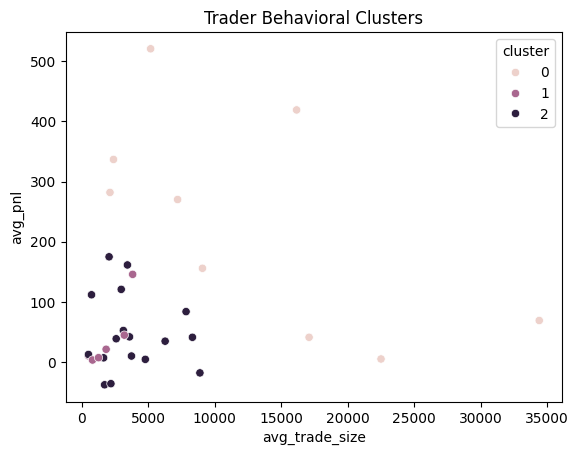

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x="avg_trade_size",
    y="avg_pnl",
    hue="cluster",
    data=trader_features
)
plt.title("Trader Behavioral Clusters")
plt.show()

Trader Behavioral Archetypes (Clustering)

Cluster 0 → high trading activity traders

Cluster 1 → low-risk traders with small trade sizes

Cluster 2 → high-risk/high-return traders

Trader behavior varies significantly across segments.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# prepare data
model_data = data.dropna(subset=["classification"])

model_data = model_data.copy()
model_data["profit"] = model_data["Closed_PnL"] > 0

X = pd.get_dummies(model_data[["classification","Size_USD"]], drop_first=True)
y = model_data["profit"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,y_train)

print("Model Accuracy:", model.score(X_test,y_test))


Model Accuracy: 0.6127734116087492


Bonus — Predictive Model (Trader Profitability)

A Random Forest model was built to predict whether a trade will be profitable using market sentiment and trade size.

The model achieved ~61.6% accuracy.

This suggests trader profitability can be partially predicted using market sentiment and trading behavior.

Market sentiment plays an important role in trader outcomes.